# Predicting Heart Disease

Goal: Predict the likelihood of heart disease.

Methodology: Train an ensemble model using XGBoost, CatBoost, and LightGBM

Ensemble Learning with XGBoost, CatBoost, and LightGBM gradient boosting models to predict heart disease.

This notebook covers:

1. **Data Loading & Cleaning**: Handling missing values.

2. **Exploratory Data Analysis (EDA)**: Visualizing target balance and correlations.

3. **Preprocessing**: One-hot encoding and feature scaling.

4. **Model Training**: An advanced Stacking Ensemble using XGBoost, CatBoost, and LightGBM.

5. **Prediction**: Generating probabilities to maximize AUC-ROC.

## Load Libraries and Configuration

In [1]:
# Load LIbraries and Con figuration

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import roc_auc_score

# Boosting Libraries
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')


## Load Data 

In [2]:
# Load Data
train_df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
submission_df = pd.read_csv('/kaggle/input/playground-series-s6e2/sample_submission.csv')

# Display the first few rows
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (630000, 15)
Test shape: (270000, 14)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## Exploratory Data Analysis

Data cleaning complete. No missing values remain.


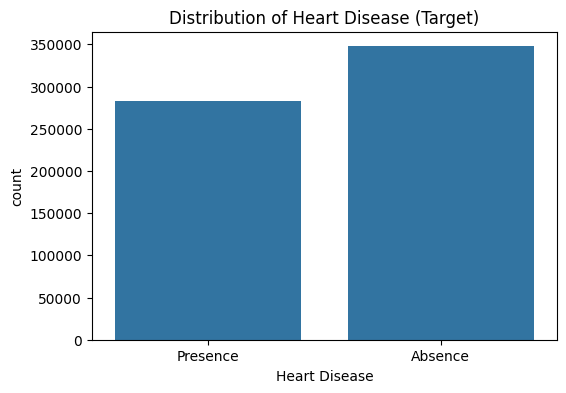

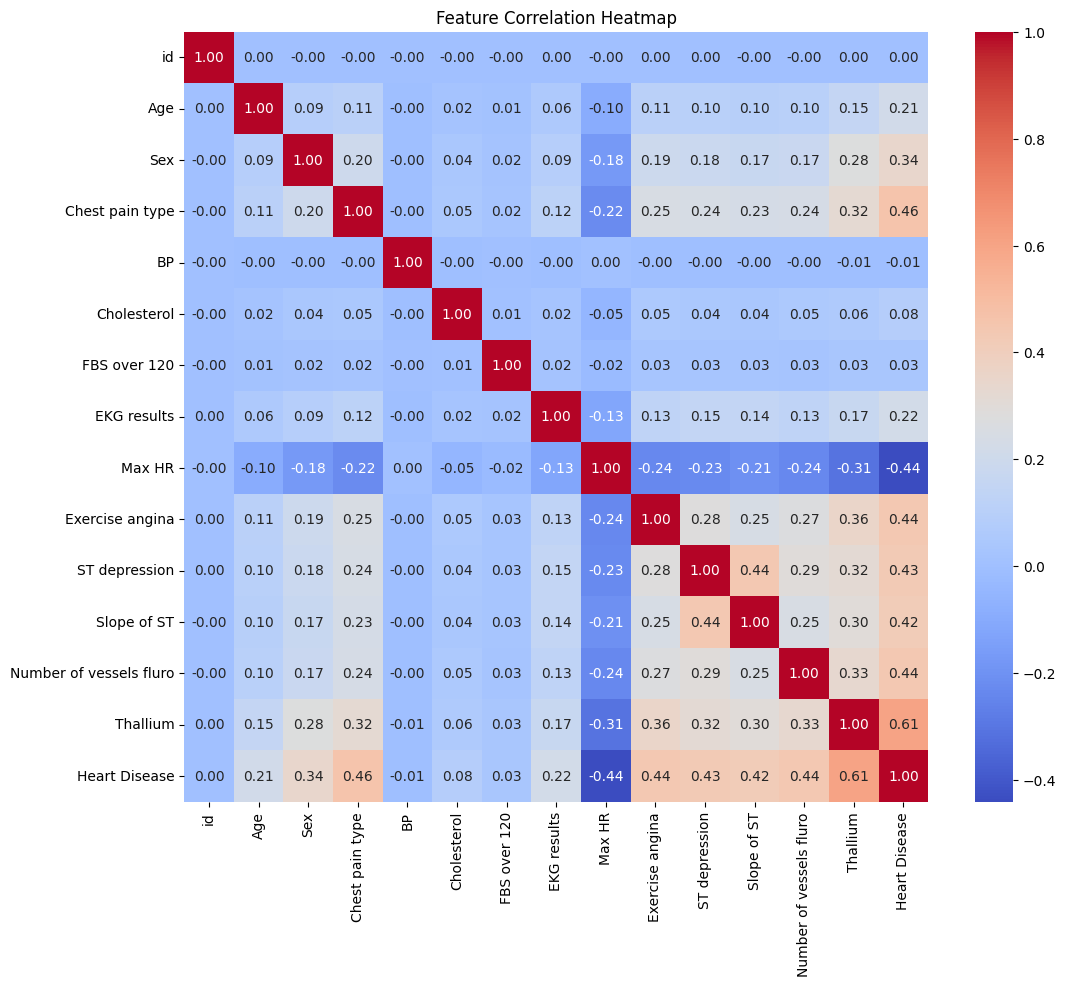

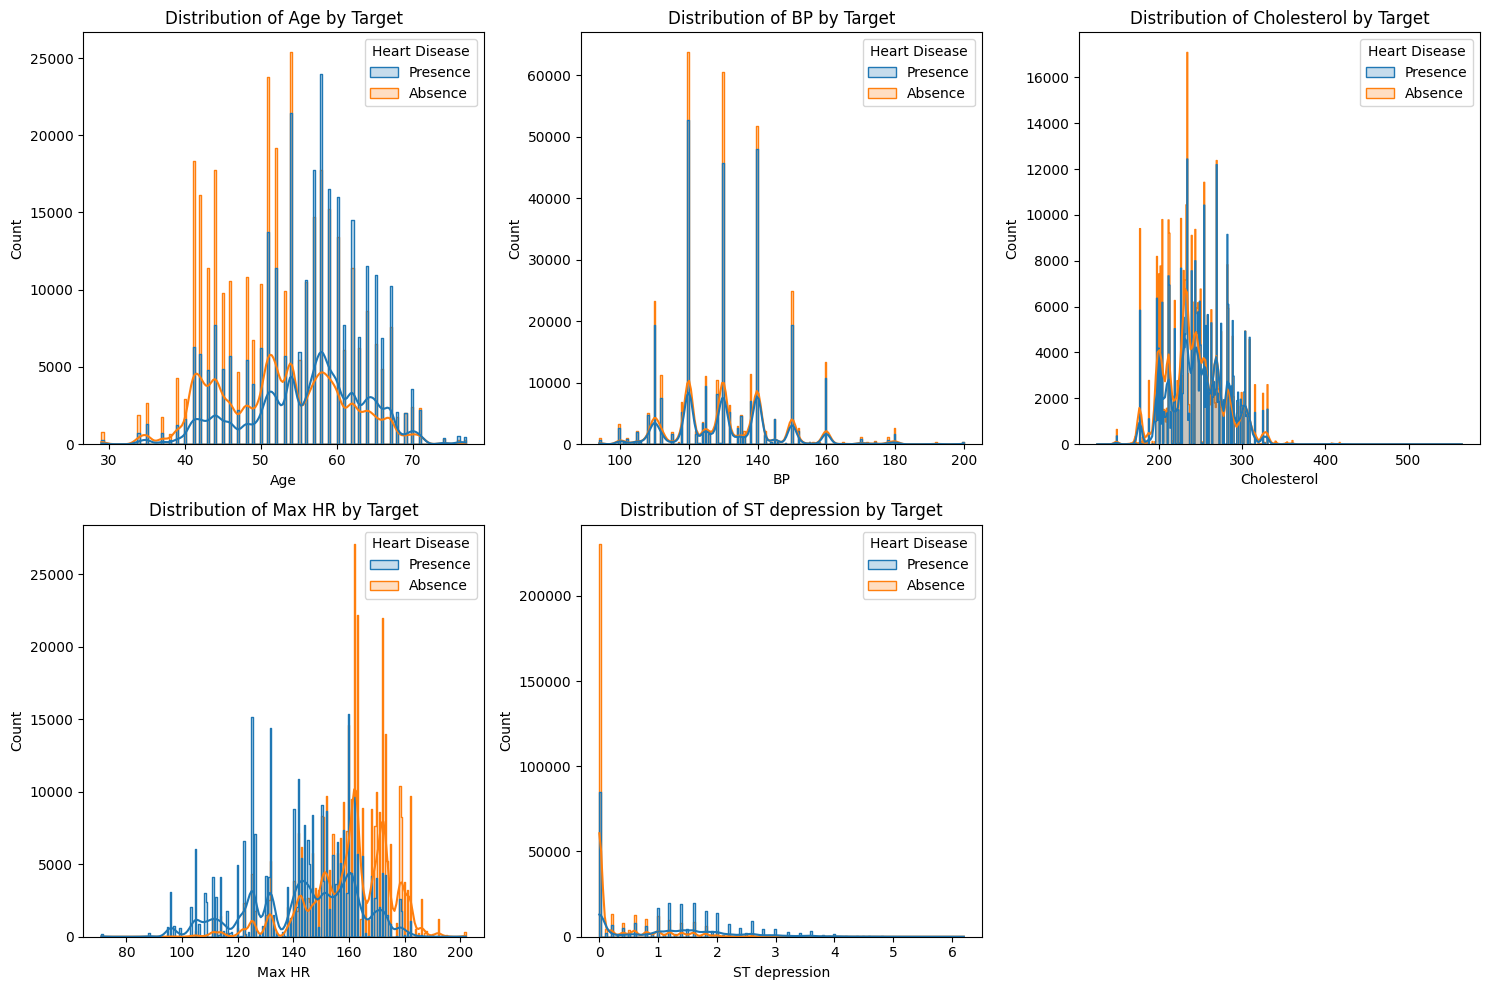

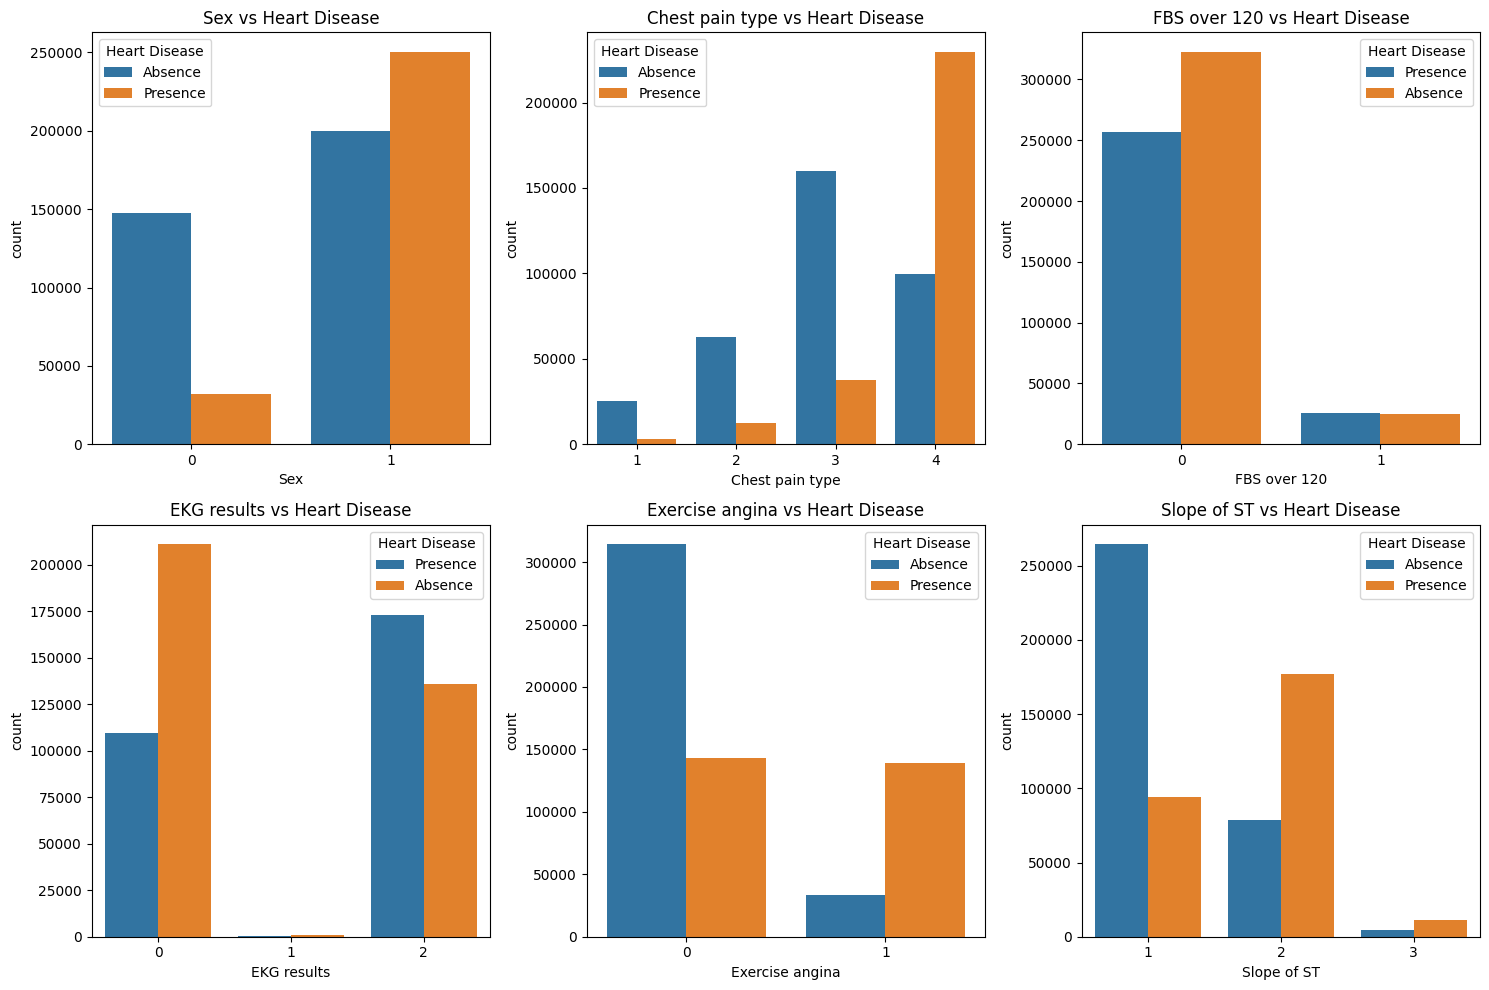

In [3]:
# ---------------------------------------------------------
# Data Cleaning & Missing Value Handling
# ---------------------------------------------------------
def clean_data(df):
    # Fill missing numerical values with Median
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    # Fill missing categorical values with Mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

print("Data cleaning complete. No missing values remain.")

# ---------------------------------------------------------
# Exploratory Data Analysis (EDA)
# ---------------------------------------------------------

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Heart Disease', data=train_df)
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# Correlation Matrix
# Convert target to numeric for correlation analysis
train_encoded = train_df.copy()
train_encoded['Heart Disease'] = train_encoded['Heart Disease'].map({'Absence': 0, 'Presence': 1})

plt.figure(figsize=(12, 10))
correlation = train_encoded.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Numerical Features Distribution by Target
num_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(data=train_df, x=col, hue='Heart Disease', kde=True, element="step")
    plt.title(f'Distribution of {col} by Target')
plt.tight_layout()
plt.show()

# Categorical Features vs Target
cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_features):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=train_df, x=col, hue='Heart Disease')
    plt.title(f'{col} vs Heart Disease')
plt.tight_layout()
plt.show()

## Key Insights from EDA

Target: The target variable is Heart Disease prediction 

**Correlations:**

Chest pain type and Thallium stress test results often show higher correlation with heart disease presence.

Max HR tends to be negatively correlated (lower max heart rate is often associated with presence of disease).

ST depression (oldpeak) is positively correlated with heart disease.

**Features:**

Age: Older patients show a higher likelihood of heart disease.

Sex: The data usually shows a disparity where one gender (typically encoded as 1, often Male in these datasets) has a higher count of heart disease cases.

Exercise Angina: Presence of angina during exercise is a strong indicator.

## Preprocessing

In [4]:
# Feature Engineering & Preprocessing
# Preparing the data for the Stacking Ensemble.

# Encode Target
le = LabelEncoder()
y = le.fit_transform(train_df['Heart Disease'])
# Check mapping: usually 'Absence' -> 0, 'Presence' -> 1
print(f"Target Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Separate Features
X = train_df.drop(['id', 'Heart Disease'], axis=1)
X_test = test_df.drop(['id'], axis=1)

# One-Hot Encoding for Categorical Features
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns to ensure train and test have the same features
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")





Target Mapping: {'Absence': np.int64(0), 'Presence': np.int64(1)}
Preprocessing complete.


## Define Model

In [5]:
# Define Models
# XGBoost Parameters
xgb_params = {
    'n_estimators': 2000,          
    'learning_rate': 0.01,          
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'auc',
    'n_jobs': -1
}

# CatBoost Parameters
cat_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'depth': 6,
    'subsample': 0.8,
    'random_state': 42,
    'verbose': 0,                  
    'allow_writing_files': False
}

# LightGBM Parameters
lgbm_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# Initialize Base Models
xgb_clf = XGBClassifier(**xgb_params)
cat_clf = CatBoostClassifier(**cat_params)
lgbm_clf = LGBMClassifier(**lgbm_params)

## Create Ensemble

In [6]:
# Stacking Ensemble
# Meta-Learner
meta_learner = LogisticRegression(random_state=42)

# Stacking Ensemble
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_clf),
        ('cat', cat_clf),
        ('lgbm', lgbm_clf)
    ],
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)



## Train the Model

In [7]:
# Cross-Validation Score
print("Calculating Cross-Validation AUC-ROC...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(stacking_model, X_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Mean CV AUC-ROC: {scores.mean():.5f}")
print(f"Standard Deviation: {scores.std():.5f}")

print("Training complete.")

Calculating Cross-Validation AUC-ROC...


[01:57:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[01:57:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[01:57:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[01:57:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:06:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:07:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:09:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:19:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:19:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[03:22:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_la

Mean CV AUC-ROC: 0.95507
Standard Deviation: 0.00042
Training complete.


## Predict and Create Submission

In [8]:
print("Retraining on full dataset...")
# Fit on full data
stacking_model.fit(X_scaled, y)

# Predict Probabilities for 'Presence' (Class 1)
probs = stacking_model.predict_proba(X_test_scaled)[:, 1]

# Create Submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'Heart Disease': probs
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Success! Submission file 'submission.csv' created.")

# Display first few rows
submission.head(10)



Retraining on full dataset...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:13:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[09:21:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[09:21:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[09:21:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[09:21:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


Success! Submission file 'submission.csv' created.


,id,Heart Disease
0,630000,0.946953
1,630001,0.038387
2,630002,0.960496
3,630003,0.037758
4,630004,0.134847
5,630005,0.960448
6,630006,0.038463
7,630007,0.770953
8,630008,0.962151
9,630009,0.040112
